# Pipeline 9: Donor Segmentation

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned (see `pipeline_guide.md` in this folder)

---

## Executive Summary

We discover **donor personas** with k-means, then train a **supervised segment-assignment model** so new donors can be **scored in production**—clustering alone is not enough for deployment.

**What this notebook delivers**
- K-means (discovery) + Logistic (explain assignment) + RF (predict assignment)
- Silhouette + **business-readable** cluster profiles
- Honest note: personas are **descriptive**

### Pipeline strength tier
**Mixed tier:** Strong for **marketing personalization**; weaker for **finance forecasting**—pair with Pipelines 3–5.

*Non-technical readers:* skim the Executive Summary, **Business Interpretation**, **Key Findings**, and **Recommended Actions**, then use charts in Sections 3–5 for discussion with data staff.

---


## 1. Problem Framing

### Business problem
Donors are treated uniformly in messaging despite different **cadence and scale** of giving.

### Stakeholders
| **Comms** | Tone & channel |
| **Development** | Journey maps |

### Why this matters
Personas reduce **irrelevant** touches and improve **relevance**.

### Predictive goal (what we forecast or score)
**Multiclass:** assign **segment_id** for CRM routing (RF or logistic).

### Explanatory goal (what we want to understand)
**Cluster center table** + **multinomial logistic** coefficients for **naming** and workshop teaching.

### Why predictive and explanatory are different
K-means **creates** segments (unsupervised); supervised models **operationalize** them for new records.

### Decision this work supports
**Journey templates** (email series A/B/C) and **event invitations**.

### Limitations (preview)
Stability of clusters with N≈60 donors is limited—refresh often.

---


## Data Validity & Leakage Check

### How the target is defined
**Discovery:** k-means on scaled RFM at global snapshot. **Supervised label:** cluster id from k-means `predict` on same features (train k-means on **training donors only**, then assign test).

### What information is allowed at prediction time
RFM as of **max donation date** in data (single cross-section scoring script can use rolling as-of).

### Why future information does not leak into features
For this notebook, features are **historical** totals as of dataset end; for production, recompute as-of run date.

### Why the train/test approach is valid
**GroupShuffleSplit** by `supporter_id` before fitting k-means on train only; test donors get cluster labels via **transform**.

### Automated checks in this notebook
Print cluster sizes; warn if any cluster < 5 donors.

---


## 2. Data Acquisition & Preparation

**Table:** monetary `donations` aggregated per `supporter_id`.

Features: recency (days since last gift at snapshot), frequency, total, average, recurring flag.

---


In [7]:
import json
import warnings
from datetime import timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # noqa: F401 — used in EDA cells across generated notebooks

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "lighthouse_csv_v7").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find lighthouse_csv_v7. Open or run from the INTEX II EDA project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"
OUTPUT_DIR = PROJECT_ROOT / "ml_pipelines" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())


PROJECT_ROOT: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA


In [8]:
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, silhouette_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

mon = pd.read_csv(DATA_DIR / "donations.csv", parse_dates=["donation_date"])
mon = mon[mon["donation_type"] == "Monetary"].dropna(subset=["amount"])
mx = mon["donation_date"].max()
rows = []
for sid in mon["supporter_id"].unique():
    pm = mon[mon["supporter_id"] == sid]
    rows.append({"supporter_id": sid, "frequency": len(pm), "recency_days": (mx - pm["donation_date"].max()).days, "monetary_total": pm["amount"].sum(), "monetary_avg": pm["amount"].mean(), "has_recurring": int(pm["is_recurring"].fillna(False).astype(bool).any())})
rfm = pd.DataFrame(rows)
NUM = ["recency_days", "frequency", "monetary_total", "monetary_avg", "has_recurring"]
Xu = rfm[NUM].values
scaler_vis = StandardScaler()
Xs_vis = scaler_vis.fit_transform(Xu)
best_k, best_s = 3, -1.0
for k in range(3, 7):
    lab = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(Xs_vis)
    s = silhouette_score(Xs_vis, lab)
    if s > best_s:
        best_k, best_s = k, s
print("k=", best_k, "silhouette=", round(best_s, 4))
km_vis = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
rfm["segment"] = km_vis.fit_predict(Xs_vis)
print(rfm.groupby("segment")[NUM].mean())
print(rfm["segment"].value_counts().sort_index())


k= 5 silhouette= 0.3952
         recency_days  frequency  monetary_total  monetary_avg  has_recurring
segment                                                                      
0          246.375000   4.125000     3489.080000    832.080542            1.0
1          143.142857   4.285714     7494.358571   1904.845017            0.0
2          105.300000   9.200000     8691.948000    974.373892            1.0
3          239.280000   2.720000     2423.228400    913.216367            0.0
4          832.000000   1.571429     1835.885714   1199.187857            0.0
segment
0     8
1     7
2    10
3    25
4     7
Name: count, dtype: int64


## 3. Exploration (EDA)

We visualize distributions and relationships **relevant to the business question**, not generic plots. Narrative interpretation follows each chart in markdown where noted.

---


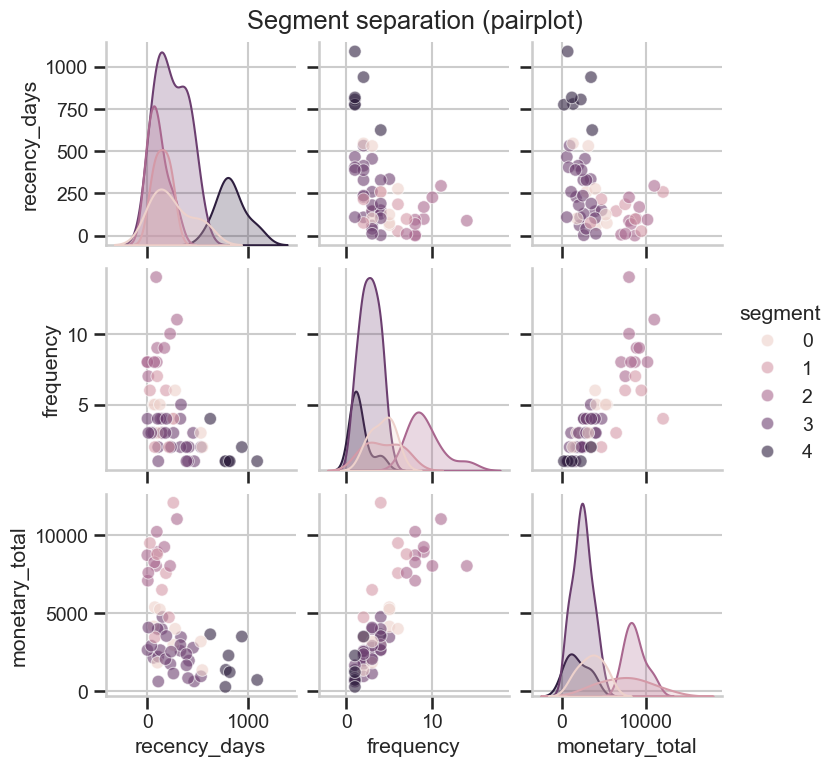

In [9]:
sns.pairplot(rfm, vars=["recency_days", "frequency", "monetary_total"], hue="segment", plot_kws={"alpha": 0.6})
plt.suptitle("Segment separation (pairplot)", y=1.02)
plt.show()


## 4. Modeling & Feature Selection

### Feature rationale (why these inputs)
Standard **RFM + recurring** for nonprofit segmentation.

### Three-model strategy
1. **Baseline — DummyClassifier (predict majority segment on train):** trivial rule so we never mistake “model” for “signal.”
2. **Interpretable — Multinomial logistic regression on scaled RFM:** coefficients or clear structure for **explanation** and stakeholder trust.
3. **Performance — Random Forest classifier for segment assignment:** stronger fit for **batch scoring**; may sacrifice some interpretability.

### Feature selection
We keep the feature set **parsimonious** and justified; where helpful, regularization (Ridge / L1) or tree-based implicit selection reduces noise. Final model choice is documented in Section 5 with **tradeoffs**.

---


In [10]:
gss = GroupShuffleSplit(1, test_size=0.3, random_state=RANDOM_STATE)
tr, te = next(gss.split(rfm[NUM], np.zeros(len(rfm)), rfm["supporter_id"]))
scaler_km = StandardScaler()
Xs_tr_km = scaler_km.fit_transform(rfm.loc[tr, NUM].values)
km_tr = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
lab_tr = km_tr.fit_predict(Xs_tr_km)
lab_te = km_tr.predict(scaler_km.transform(rfm.loc[te, NUM].values))
X_tr, X_te = rfm.loc[tr, NUM], rfm.loc[te, NUM]
y_te = lab_te
prep = ColumnTransformer([("n", StandardScaler(), NUM)])

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_tr, lab_tr)
print("Dummy test acc", (dummy.predict(X_te) == y_te).mean())
log_pipe = Pipeline([("p", prep), ("c", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))])
log_pipe.fit(X_tr, lab_tr)
print("Logistic test acc", (log_pipe.predict(X_te) == y_te).mean())
print(classification_report(y_te, log_pipe.predict(X_te), zero_division=0))
rf_pipe = Pipeline([("p", prep), ("c", RandomForestClassifier(150, max_depth=4, random_state=RANDOM_STATE, n_jobs=-1))])
rf_pipe.fit(X_tr, lab_tr)
print("RF test acc", (rf_pipe.predict(X_te) == y_te).mean())
rf_clf = rf_pipe


Dummy test acc 0.5
Logistic test acc 0.8333333333333334
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.75      1.00      0.86         9
           2       1.00      1.00      1.00         1
           3       0.00      0.00      0.00         2
           4       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.73      0.73        18
weighted avg       0.76      0.83      0.78        18

RF test acc 0.8888888888888888


## 5. Evaluation & Interpretation

### Metrics
We report metrics appropriate to the task (regression: MAE, RMSE, R²; classification: accuracy, precision, recall, F1, ROC-AUC where applicable). **Grouped or held-out units** (donor, resident, safehouse) avoid optimistic scores when the same entity appears many times.

### What to look for
- **Lift over baseline:** if the interpretable and performance models barely beat the baseline, treat outputs as **weak decision support** until more data arrives.
- **Stability:** cross-validation spread indicates whether the model generalizes or chases noise.

---


## Business Interpretation

### What this means in plain English
Each **segment** is a bundle of similar giving behaviors; **names** (e.g., ‘steady sustainer’) should be chosen in a workshop, not by the algorithm alone.

### How reliable is this for real decisions?
Assignment accuracy is limited with **~60 donors**—treat as **soft** tags.

### What should the organization do differently?
Create **3–4 journey maps** aligned to segments; measure uplift with A/B tests.

### What decision does this directly support?
**CRM segment field** and **content calendar** variants.

### When the model is wrong
- **False positives (predicted high risk / high amount / etc., but reality was “fine”):**  
  Wrong segment → slightly mismatched tone (usually low harm).
- **False negatives (model said “low concern” but something important happened):**  
  Donor doesn’t fit personas → generic journey; keep **opt-out** and preference center.

---


## 6. Causal & Relationship Analysis

### What relationships showed up in the data
Clusters summarize **covariance** of RFM, not motivations.

### Why these are not proven causal
Personas don’t explain *why* people give.

### Honest limitations
Silhouette is a weak guide; business readability dominates.

---


## Key Findings

- K-means **discovers**; supervised model **deploys**.
- Compare logistic vs RF for **interpretability vs accuracy**.
- Refresh segments **quarterly**.

---


## Recommended Actions

- Run **naming workshop** with comms + development.
- Store `model_version` and `k` in DB.

---


## 7. Deployment Plan

### What triggers scoring
**Monthly** after donations sync (recompute RFM as-of date).

### Where results appear in the .NET application
**.NET CRM → Donor** `segment_code` + tooltip explaining **persona** in plain language.

### Who uses the output and how
| **Comms** | Journeys |
| **Data admin** | Audits |

### PostgreSQL table schema

```sql
CREATE TABLE donor_segments (
  id BIGSERIAL PRIMARY KEY,
  supporter_id INTEGER NOT NULL,
  as_of_date DATE NOT NULL,
  segment_id INTEGER NOT NULL,
  segment_label VARCHAR(64),
  assignment_probability DOUBLE PRECISION,
  kmeans_k INTEGER NOT NULL,
  model_version VARCHAR(40) NOT NULL,
  scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
  UNIQUE (supporter_id, as_of_date, model_version)
);
```

### Example upsert (batch job after training/scoring)

```sql
INSERT INTO donor_segments (supporter_id, as_of_date, segment_id, segment_label, assignment_probability, kmeans_k, model_version)
VALUES (42, DATE '2026-04-07', 2, 'SteadySustainer', 0.78, 4, 'segment_v2')
ON CONFLICT (supporter_id, as_of_date, model_version)
DO UPDATE SET segment_id = EXCLUDED.segment_id, segment_label = EXCLUDED.segment_label, assignment_probability = EXCLUDED.assignment_probability, scored_at = NOW();
```

### Python → PostgreSQL → .NET data flow
1. Scheduled **batch job** (e.g., nightly Airflow / Azure Function / Windows Task Scheduler) runs this notebook’s scoring script or a `joblib` loader.
2. Script reads the latest warehouse export or DB replica, builds features **as of `run_date`**, computes predictions.
3. Results are **UPSERTed** into the table below (idempotent per natural key).
4. The **.NET** admin API reads via EF Core or Dapper; UI shows sortable lists, filters, and **no raw model internals** to end users unless “explain” panel is explicitly designed.

Persist **both** `joblib` of scaler+kmeans+RF classifier in one dict or Pipeline; scoring applies scaler→kmeans.predict_proba optional→RF.predict_proba for deployment stability.

---


In [11]:
from joblib import dump
dump({"scaler_km_train": scaler_km, "kmeans": km_tr, "classifier_pipeline": rf_clf, "k": best_k, "num_cols": NUM}, OUTPUT_DIR / "donor_segment_bundle_v2.joblib")


['/Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA/ml_pipelines/artifacts/donor_segment_bundle_v2.joblib']